In [1]:
!pip install torch torchvision torchaudio
!pip install git+https://github.com/RobustBench/robustbench.git
!pip install git+https://github.com/fra31/auto-attack
!pip install matplotlib

  Cloning https://github.com/RobustBench/robustbench.git to /tmp/pip-req-build-l0ak05eo
  Running command git clone --filter=blob:none --quiet https://github.com/RobustBench/robustbench.git /tmp/pip-req-build-l0ak05eo
  Resolved https://github.com/RobustBench/robustbench.git to commit 78fcc9e48a07a861268f295a777b975f25155964
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to /tmp/pip-install-k94um1qg/autoattack_9b4a3baa4b814057999c768b7d64137c
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /tmp/pip-install-k94um1qg/autoattack_9b4a3baa4b814057999c768b7d64137c
  Running command git rev-parse -q --verify 'sha^a39220048b3c9f2cca9a4d3a54604793c68eca7e'
  Running command git fetch -q https://github.com/fra31/auto-attack.git a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4

In [2]:
#prepares the environment and decides whether computation will run on CPU
import torch
from robustbench import load_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [3]:
#load two RobustBench models
model_a = load_model(
    model_name="Standard",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_b = load_model(
    model_name="Engstrom2019Robustness",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_a.eval()
model_b.eval()

print(type(model_a))
print(type(model_b))

Downloading...
From (original): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC
From (redirected): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC&confirm=t&uuid=032e85e0-3c7d-4bb0-8673-05cab37a892f
To: /content/models/cifar10/Linf/Standard.pt
100%|██████████| 292M/292M [00:04<00:00, 67.6MB/s]


Downloading...
From: https://drive.google.com/uc?id=1etqmQsksNIWBvBQ4r8ZFk_3FJlLWr8Rr
To: /content/models/cifar10/Linf/Engstrom2019Robustness.pt
100%|██████████| 94.4M/94.4M [00:02<00:00, 39.8MB/s]

<class 'robustbench.model_zoo.architectures.wide_resnet.WideResNet'>
<class 'robustbench.model_zoo.cifar10.Engstrom2019RobustnessNet'>


In [4]:
#test that both models run correctly
x = torch.randn(1, 3, 32, 32).to(device)

with torch.no_grad():
    y_a = model_a(x)
    y_b = model_b(x)

print("Model A output shape:", y_a.shape)
print("Model B output shape:", y_b.shape)

Model A output shape: torch.Size([1, 10])
Model B output shape: torch.Size([1, 10])


In [5]:
#load real CIFAR-10 test data
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print("Test set loaded:", len(test_dataset))

100%|██████████| 170M/170M [00:05<00:00, 30.0MB/s]


Test set loaded: 10000


In [6]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([8, 3, 32, 32])
Labels shape: torch.Size([8])
Labels: tensor([3, 8, 8, 0, 6, 6, 1, 6], device='cuda:0')


In [7]:
#compare predictions of the two models
with torch.no_grad():
    out_a = model_a(images)
    out_b = model_b(images)

print("Model A output shape:", out_a.shape)
print("Model B output shape:", out_b.shape)


Model A output shape: torch.Size([8, 10])
Model B output shape: torch.Size([8, 10])


In [8]:
#compare predictions of the two models
pred_a = out_a.argmax(dim=1)
pred_b = out_b.argmax(dim=1)

print("True labels: ", labels.cpu().tolist())
print("Pred A:      ", pred_a.cpu().tolist())
print("Pred B:      ", pred_b.cpu().tolist())

True labels:  [3, 8, 8, 0, 6, 6, 1, 6]
Pred A:       [3, 8, 8, 0, 6, 6, 1, 6]
Pred B:       [3, 8, 8, 0, 6, 6, 1, 6]


In [9]:
#Count how many predictions each model got correct in this batch
correct_a = (pred_a == labels).sum().item()
correct_b = (pred_b == labels).sum().item()

print(f"Model A correct: {correct_a}/{labels.size(0)}")
print(f"Model B correct: {correct_b}/{labels.size(0)}")

Model A correct: 8/8
Model B correct: 8/8


In [10]:
#converts numeric class IDs into human-readable CIFAR-10 names
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

for i in range(len(labels)):
    print(f"Image {i}: true={classes[labels[i].item()]}, "
          f"model_a={classes[pred_a[i].item()]}, "
          f"model_b={classes[pred_b[i].item()]}")

Image 0: true=cat, model_a=cat, model_b=cat
Image 1: true=ship, model_a=ship, model_b=ship
Image 2: true=ship, model_a=ship, model_b=ship
Image 3: true=airplane, model_a=airplane, model_b=airplane
Image 4: true=frog, model_a=frog, model_b=frog
Image 5: true=frog, model_a=frog, model_b=frog
Image 6: true=automobile, model_a=automobile, model_b=automobile
Image 7: true=frog, model_a=frog, model_b=frog


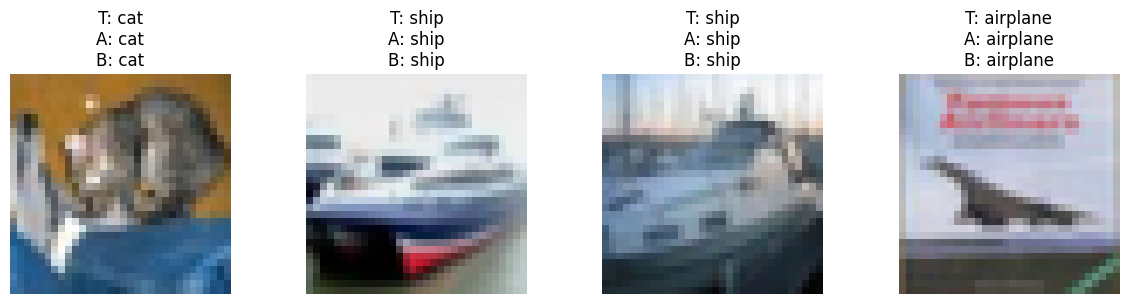

In [11]:
#Show a few images from the batch
import matplotlib.pyplot as plt

num_show = 4
fig, axes = plt.subplots(1, num_show, figsize=(12, 3))

for i in range(num_show):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(
        f"T: {classes[labels[i].item()]}\n"
        f"A: {classes[pred_a[i].item()]}\n"
        f"B: {classes[pred_b[i].item()]}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
#Measure clean accuracy on a few batches instead of just one
num_batches = 20
total = 0
correct_a = 0
correct_b = 0

with torch.no_grad():
    for batch_idx, (imgs, lbls) in enumerate(test_loader):
        if batch_idx >= num_batches:
            break

        imgs = imgs.to(device)
        lbls = lbls.to(device)

        out_a = model_a(imgs)
        out_b = model_b(imgs)

        pred_a = out_a.argmax(dim=1)
        pred_b = out_b.argmax(dim=1)

        correct_a += (pred_a == lbls).sum().item()
        correct_b += (pred_b == lbls).sum().item()
        total += lbls.size(0)

print(f"Model A clean accuracy on {total} images: {correct_a/total:.4f}")
print(f"Model B clean accuracy on {total} images: {correct_b/total:.4f}")

Model A clean accuracy on 160 images: 0.9437
Model B clean accuracy on 160 images: 0.9125


In [13]:
#Save one clean batch for later adversarial experiments
clean_images = images.clone().detach()
clean_labels = labels.clone().detach()

print("Saved clean batch:", clean_images.shape, clean_labels.shape)

Saved clean batch: torch.Size([8, 3, 32, 32]) torch.Size([8])


In [14]:
from autoattack import AutoAttack

attacker_a = AutoAttack(
    model_a,
    norm='Linf',
    eps=8/255,
    version='standard',
    device=device
)

print("AutoAttack ready")

setting parameters for standard version
AutoAttack ready


In [15]:
#Run AutoAttack on the clean batch for model_a
adv_images_a = attacker_a.run_standard_evaluation(
    clean_images,
    clean_labels,
    bs=8
)

using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 8 out of 8 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 4.8 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%


In [16]:
#Evaluate model_a on the adversarial examples
with torch.no_grad():
    adv_out_a = model_a(adv_images_a)

adv_pred_a = adv_out_a.argmax(dim=1)

print("True labels: ", clean_labels.cpu().tolist())
print("Adv pred A:  ", adv_pred_a.cpu().tolist())

acc_a = (adv_pred_a == clean_labels).sum().item()
print(f"Model A accuracy on adversarial examples: {acc_a}/{clean_labels.size(0)}")

True labels:  [3, 8, 8, 0, 6, 6, 1, 6]
Adv pred A:   [6, 1, 2, 8, 4, 3, 3, 3]
Model A accuracy on adversarial examples: 0/8


Eps: 0.0 | ASR Std: 0.0% | ASR Robust: 0.0%
setting parameters for standard version
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 8 out of 8 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 4.5 s)
max Linf perturbation: 0.00784, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 1 out of 8 successfully perturbed
robust accuracy after APGD-CE: 87.50% (total time 2.3 s)
apgd-t - 1/1 - 0 out of 7 successfully perturbed
robust accuracy after APGD-T: 87.50% (total time 22.3 s)
fab-t - 1/1 - 0 out of 7 successfully perturbed
robust accuracy after FAB-T: 87.50% (total time 66.0 s)
square - 1/1 - 0 out of 7 successfully perturbed
robust accuracy after SQUARE: 87.50% (total time 121.7 s)
max Linf perturbation: 0.00784, nan in tensor: 0, max: 1.00000, 

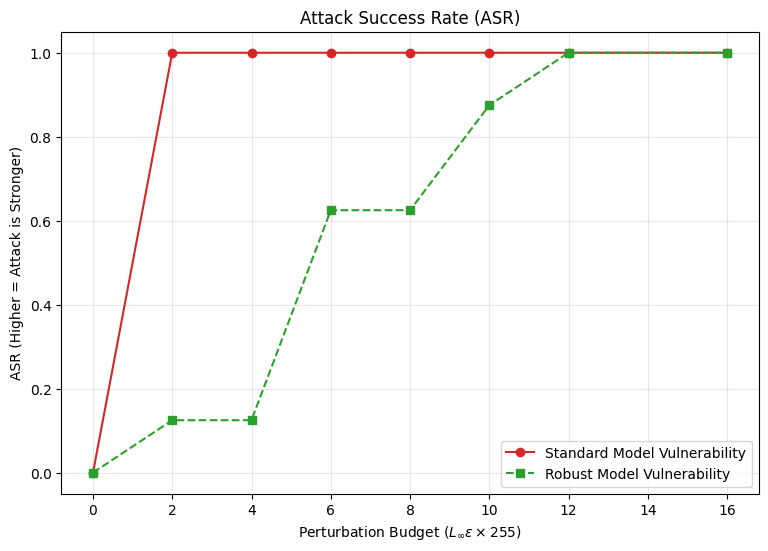

In [17]:
import matplotlib.pyplot as plt
import torch
from autoattack import AutoAttack

#Setup
subset_size = 50
epsilons = [0, 2/255, 4/255, 6/255, 8/255, 10/255, 12/255, 16/255]
asr_model_a, asr_model_b = [], []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
images_sub = clean_images[:subset_size].to(device)
labels_sub = clean_labels[:subset_size].to(device)

for eps in epsilons:
    if eps == 0:
        asr_model_a.append(0.0)
        asr_model_b.append(0.0)
        print(f"Eps: 0.0 | ASR Std: 0.0% | ASR Robust: 0.0%")
        continue

    att_a = AutoAttack(model_a, norm='Linf', eps=eps, version='standard', device=device, verbose=True)
    att_b = AutoAttack(model_b, norm='Linf', eps=eps, version='standard', device=device, verbose=True)

    with torch.no_grad():
        # Clean predictions to identify initially correct samples
        out_a = model_a(images_sub).max(1)[1]
        out_b = model_b(images_sub).max(1)[1]

        correct_idx_a = (out_a == labels_sub)
        correct_idx_b = (out_b == labels_sub)

        # Run AutoAttack
        _, l_adv_a = att_a.run_standard_evaluation(images_sub, labels_sub, bs=subset_size, return_labels=True)
        _, l_adv_b = att_b.run_standard_evaluation(images_sub, labels_sub, bs=subset_size, return_labels=True)

    # Calculate ASR only for samples that were originally correct
    success_a = correct_idx_a & (l_adv_a != labels_sub)
    success_b = correct_idx_b & (l_adv_b != labels_sub)

    # Use .item() only if it's a tensor, and handle potential division by zero
    val_a = (success_a.float().sum() / correct_idx_a.float().sum()).item() if correct_idx_a.any() else 0.0
    val_b = (success_b.float().sum() / correct_idx_b.float().sum()).item() if correct_idx_b.any() else 0.0

    asr_model_a.append(val_a)
    asr_model_b.append(val_b)

    print(f"Eps: {eps*255:.1f}/255 | ASR Std: {val_a*100:.1f}% | ASR Robust: {val_b*100:.1f}%")


plt.figure(figsize=(9, 6))
plt.plot([e*255 for e in epsilons], asr_model_a, 'o-', color='#d62728', label='Standard Model Vulnerability')
plt.plot([e*255 for e in epsilons], asr_model_b, 's--', color='#2ca02c', label='Robust Model Vulnerability')

plt.title('Attack Success Rate (ASR)')
plt.xlabel(r'Perturbation Budget ($L_{\infty} \epsilon \times 255$)')
plt.ylabel('ASR (Higher = Attack is Stronger)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Key Findings:

The standard model exhibited a 100% Attack Success Rate (ASR) almost immediately, starting at  ϵ=2/255 . It was consistently compromised by the first and simplest attack in the ensemble (APGD-CE) in under 5 seconds, confirming a lack of defensive margin.

The robust model demonstrated a significantly higher resistance. At the common benchmark of  ϵ=8/255 , it maintained a 37.5% Robust Accuracy (62.5% ASR).

While the standard model failed instantly, the robust model forced the attacker to utilize the full ensemble. In several cases, it resisted gradient-based attacks (APGD) and only failed when subjected to the computationally expensive Square Attack (black-box), or resisted the entire ensemble altogether.

The time required to find an adversarial example was approximately 30x higher for the robust model, highlighting its practical security advantage in real-world scenarios.

<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_456/799889928.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.suptitle(f"Adversarial Analysis at $\epsilon$ = {eps*255:.1f}/255", fontsize=14)


Visualizing Standard Model Vulnerabilities (Eps 8/255):


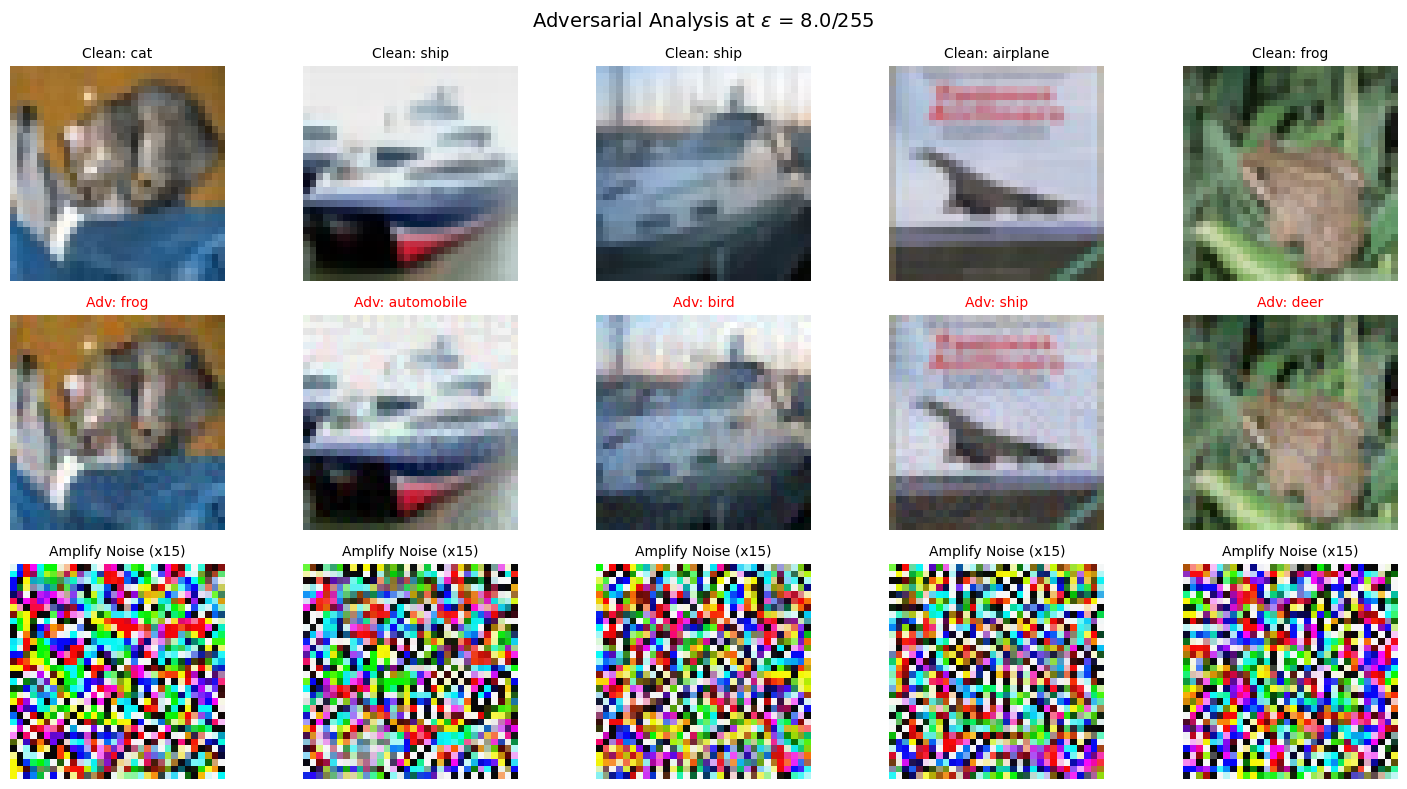

Visualizing Robust Model Defense (Eps 8/255):


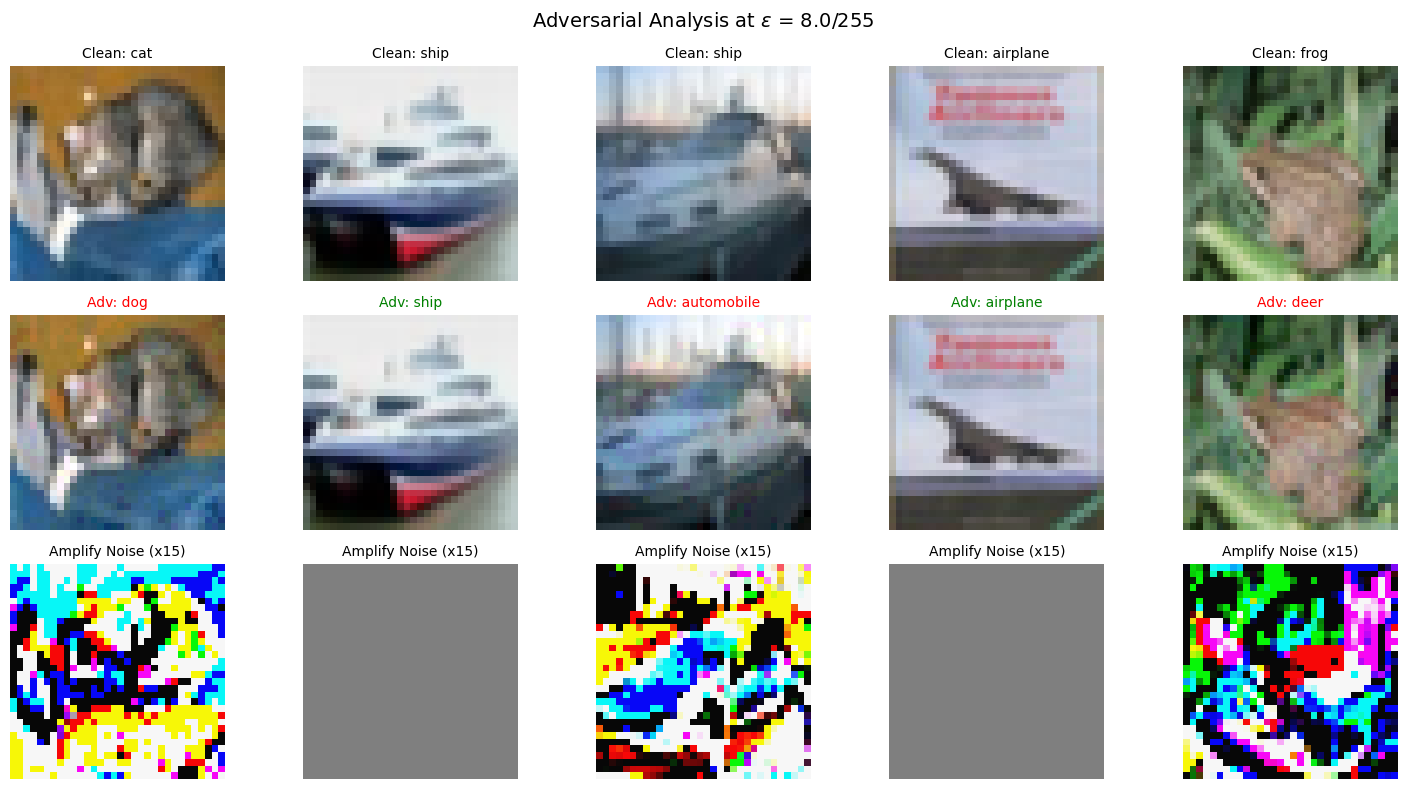

In [18]:
def visualize_adversarial_examples(model, images, labels, eps=8/255, n_display=5):
    images_to_attack = images[:n_display].to(device)
    labels_to_attack = labels[:n_display].to(device)

    attacker = AutoAttack(model, norm='Linf', eps=eps, version='standard', device=device, verbose=False)
    adv_images = attacker.run_standard_evaluation(images_to_attack, labels_to_attack, bs=n_display)

    # Calculate perturbation
    perturbation = adv_images - images_to_attack
    # Amplify noise: 0.5 is the neutral gray for the difference
    amplified_noise = torch.clamp(perturbation * 15 + 0.5, 0, 1)

    def to_np(t):
        return t.permute(1, 2, 0).detach().cpu().numpy()

    fig, axes = plt.subplots(3, n_display, figsize=(n_display * 3, 8))
    classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    for i in range(n_display):
        # Row 1: Clean
        axes[0, i].imshow(to_np(images_to_attack[i]))
        axes[0, i].set_title(f"Clean: {classes[labels_to_attack[i]]}", fontsize=10)
        axes[0, i].axis('off')

        # Row 2: Adversarial
        axes[1, i].imshow(to_np(adv_images[i]))
        with torch.no_grad():
            pred = model(adv_images[i].unsqueeze(0)).argmax().item()
        color = 'red' if pred != labels_to_attack[i] else 'green'
        axes[1, i].set_title(f"Adv: {classes[pred]}", fontsize=10, color=color)
        axes[1, i].axis('off')

        # Row 3: Noise (The "Fingerprint" of the attack)
        axes[2, i].imshow(to_np(amplified_noise[i]))
        axes[2, i].set_title("Amplify Noise (x15)", fontsize=10)
        axes[2, i].axis('off')

    plt.suptitle(f"Adversarial Analysis at $\epsilon$ = {eps*255:.1f}/255", fontsize=14)
    plt.tight_layout()
    plt.show()


print("Visualizing Standard Model Vulnerabilities (Eps 8/255):")
visualize_adversarial_examples(model_a, clean_images, clean_labels, eps=8/255)

print("Visualizing Robust Model Defense (Eps 8/255):")
visualize_adversarial_examples(model_b, clean_images, clean_labels, eps=8/255)

In the visualization above, titles are color-coded to indicate the model's success. Red titles denote successful adversarial attacks where the model was misdirected. Green titles represent a successful defense, where the model's prediction remained consistent with the ground truth despite the perturbation.

